Import packages

In [10]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

from sklearn.neighbors import NearestNeighbors
from cdlib.benchmark import LFR
from node2vec import Node2Vec # https://github.com/eliorc/node2vec


Genera grafo

In [7]:
G,coms = LFR(
    n=500,
    tau1=3, # se + piccolo —> clustering + difficile
    tau2=2.0, # dimensioni per ogni comunità —> se piccolo: grandi differenze tra le comunità
    mu=0.1, # piccolo: comunità ben definite , + grande : comunità difficili da riconoscere
    average_degree=5,
    min_community=20,
    tol=1e-5,
    max_iters=1000, # più tentativi per trovare una partizione valida
    seed=42
)

G.remove_edges_from(nx.selfloop_edges(G)) # toglie self-loops, non penso che vogliamo averne

print(G) # graph
gt_coms = coms.communities # ground truth communities
print("Communities: ",coms.communities)


Graph with 500 nodes and 1030 edges
Communities:  [[256, 6, 393, 138, 140, 396, 19, 404, 277, 24, 414, 163, 164, 423, 167, 40, 298, 44, 173, 46, 48, 432, 50, 435, 307, 196, 458, 331, 205, 82, 212, 475, 224, 481, 228, 232, 116, 121, 250], [0, 131, 387, 5, 255, 135, 269, 144, 147, 150, 425, 42, 302, 49, 184, 59, 60, 454, 74, 462, 206, 465, 209, 469, 348, 222, 351, 99, 107, 499, 376, 249, 252, 127], [8, 394, 266, 141, 399, 15, 401, 146, 17, 278, 151, 168, 41, 170, 172, 428, 306, 313, 66, 453, 327, 328, 73, 332, 211, 83, 490, 491, 364, 493, 363, 111, 374, 118], [398, 273, 21, 406, 22, 408, 410, 413, 160, 32, 291, 420, 297, 43, 304, 433, 308, 180, 310, 52, 57, 314, 190, 191, 319, 320, 324, 68, 460, 334, 340, 216, 92, 359], [257, 149, 25, 284, 157, 30, 159, 416, 417, 418, 29, 34, 165, 166, 427, 175, 183, 55, 311, 446, 62, 207, 464, 344, 479, 484, 233, 108, 110, 498, 114, 380], [2, 322, 455, 201, 79, 343, 153, 409, 411, 412, 154, 473, 287, 352, 422, 360, 489, 361, 494, 367, 496, 246, 248, 58,

Show graph

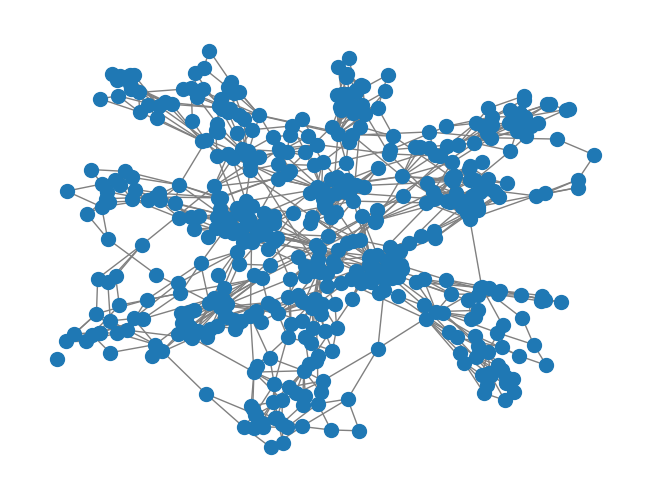

In [8]:
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos,
        node_size = 100,
        edge_color = "gray")
plt.show()

Ricava node2vec embeddings

In [14]:
# create model
node2vec_model = Node2Vec(G, seed=123) # tutti i parametri sono su default -> VALUTARE SE FARE MODIFICHE, dipende da n, parametri q e p migliori per community detection ecc.

# train the model
embeddings = node2vec_model.fit()

# output works like a dictionary, key = node_id
vector_n2v = embeddings.wv['0'] # embedding of node 0

print(vector_n2v)

# convert embeddings into a numpy array
model_wv = embeddings.wv # this gets all keyed vectors in the attribute .wv
nodes = sorted(list(G.nodes())) # get nodes list from original graph
X = np.array([model_wv[str(n)] for n in nodes]) # do the lookup in model_wv node by node, convert 'n' to str() because node2vec stores keys as strings

print("Embeddings array shape: ",X.shape)

Generating walks (CPU: 1): 100%|██████████| 10/10 [00:01<00:00,  6.17it/s]


[ 0.22774203 -0.29172203 -0.11011484  0.40700924 -0.18516365 -0.41771677
  0.3337808   0.32255715 -0.47931603  0.36030373  0.12280472  0.39948905
  0.433106    0.0286954   0.34034297  0.33027536 -0.12618983 -0.1802116
 -0.07676819  0.38315308 -0.10031252  0.30889308 -0.4442329  -0.36894113
 -0.75274605  0.3727415   0.36584005  0.6479641  -0.21030222 -0.40754753
  0.15209009  0.20149818 -0.47694862  0.3907031   0.287945    0.7017533
  0.1285729   0.05663081 -0.19765532 -0.2861304  -0.10643151  0.3709378
  0.179203    0.02107351 -0.11307803  0.27730313  0.20190239 -0.06715958
 -0.45579186 -0.21622877  0.7123453  -0.06450547  0.01369279 -0.04402744
  0.39798215 -0.07713683  0.09524928 -0.28804657 -0.6534352   0.22529593
 -0.01438742  0.31586194  0.47507203 -0.47100627 -0.17759156 -0.16471823
  0.14683783 -0.02998665  0.3919542   0.3546386  -0.2337921  -0.28188613
  0.01054834 -0.17726468  0.01267159 -0.08602536  0.6932523  -0.4368146
  0.51791817  0.32919732 -0.07390312  0.04930928  0.458

Codice per ricostruzione

In [21]:
k = np.round((2 * G.number_of_edges()) / G.number_of_nodes()) # average node degree
# get knn model
knn = NearestNeighbors(n_neighbors=k+1, metric='cosine') # use k+1 because the first neighbor is always the node itself (distance=0)
knn.fit(X)
distances, indices = knn.kneighbors(X)

# get the list of edges to add to the reconstructed graph
# qua dentro volendo possiamo anche aggiungere come edge weight nel grafo ricostruito la cosine similarity tra i nodi collegati dall'arco, non so se può servire agli algoritmi di community detection come parametro
edge_list = []
for i, neighbor_indices in enumerate(indices):
    u = nodes[i]
    for neighbor_idx in neighbor_indices[1:]: # skip the first element because it is the node itself
        v = nodes[neighbor_idx]
        edge_list.append((u, v))

# add edges to the reconstructed graph
reconstructed_graph = nx.Graph()
reconstructed_graph.add_edges_from(edge_list)

print("Reconstructed graph has", reconstructed_graph.number_of_edges(),"edges.")
print("Is reconstructed graph connected?", nx.is_connected(reconstructed_graph))


Reconstructed graph has 1538 edges.
Is reconstructed graph connected? True


Mostra grafo ricostruito

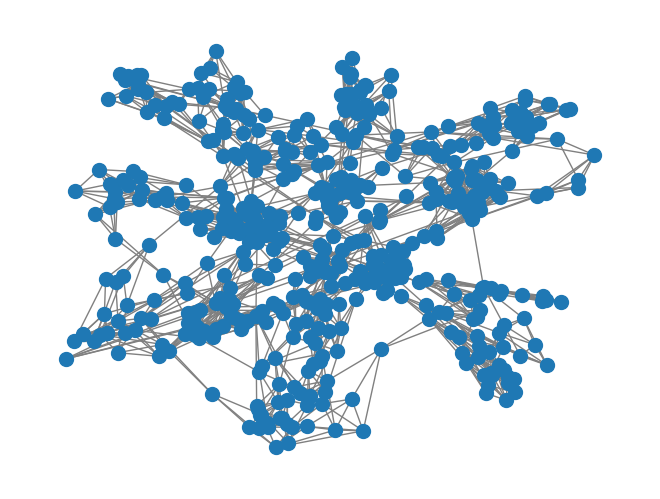

In [19]:
reconstructed_pos = nx.spring_layout(G, seed=42)
nx.draw(reconstructed_graph, reconstructed_pos,
        node_size = 100,
        edge_color = "gray")
plt.show()